# Lab 5 Report:
## Create Arthur Conan Doyle AI with RNN

### Name:

In [16]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.distributions import Categorical

In [17]:
# Extra cell to direct to correct directory
import os
from google.colab import drive

drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/UW Lab Materials/Lab5_Template/Lab5_Template')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [ ]:
Image('lab5_exercise.png', width = 1000)

## Prepare Data

In [19]:
# You will train on the first N characters of the Sherlock Holmes book
# Pick the size of your training data, i.e. N
data_size_to_train = 1000000 # YOUR CODE HERE

# Load the Sherlock Holmes data up to data_size_to_train
# YOUR CODE HERE
data = open('sherlock.txt', 'r').read()
data = data[:data_size_to_train]

# Find the set of unique characters within the training data
characters = sorted(list(set(data))) # YOUR CODE HERE

# total number of characters in the training data and number of unique characters
data_size, vocab_size = len(data), len(characters)

print("Data has {} characters, {} unique".format(data_size, vocab_size))

Data has 1000000 characters, 92 unique


In [20]:
# Use Python Dictionary to map the characters to numbers and vice versa

# YOUR CODE HERE
character_to_num = {ch:i for i, ch in enumerate(characters)}
num_to_character = {i:ch for i, ch in enumerate(characters)}

In [21]:
# Use the character_to_num dictionary to map each character in the training dataset to a number

# YOUR CODE HERE
data_num = [character_to_num[ch] for ch in data]

## Define Model

In [22]:
class CharRNN(torch.nn.Module):

    def __init__(self, num_embeddings, embedding_dim, input_size, hidden_size, num_layers, output_size):

        super(CharRNN, self).__init__()

        # YOUR CODE HERE

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = torch.nn.Embedding(num_embeddings, embedding_dim)
        self.rnn = torch.nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, output_size)


    def forward(self, input_seq, hidden_state):

        # YOUR CODE HERE

        if hidden_state is None:
            batch_size = input_seq.size(0)
            hidden_state = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(input_seq.device)

        input_seq = self.embedding(input_seq)
        output, hidden_state = self.rnn(input_seq, hidden_state)
        output = self.fc(output)
        return output, hidden_state

## Define Hyperparameters

In [39]:
# Fix random seed
torch.manual_seed(25)

# Define RNN network
rnn = CharRNN(vocab_size, 64, 64, 100, 1, vocab_size) # YOUR CODE HERE

# Define learning rate and epochs
learning_rate = 0.1 # YOUR CODE HERE
epochs = 25 # YOUR CODE HERE

# Size of the input sequence to be used during training and validation
training_sequence_len = 25 # YOUR CODE HERE
validation_sequence_len = 150 # YOUR CODE HERE

# Define loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss() # YOUR CODE HERE
optimizer = torch.optim.Adagrad(rnn.parameters(), lr=learning_rate) # YOUR CODE HERE

# add .cuda() for GPU acceleration
#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rnn = rnn.to(device)
rnn

CharRNN(
  (embedding): Embedding(92, 64)
  (rnn): RNN(64, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=92, bias=True)
)

## Identify Tracked Values

In [29]:
# Tracking training loss per each input/target sequence fwd/bwd pass
# YOUR CODE HERE
train_loss_list = []

## Train Model

In [32]:
# Convert training data into torch tensor and make it into vertical orientation (N, 1)
# Attach .cuda() if using GPU
data = torch.tensor(data_num).unsqueeze(1).to(device) # YOUR CODE HERE

# Training Loop ----------------------------------------------------------------------------------------------------------

for epoch in range(epochs):

    # YOUR CODE HERE
    p = 0
    hprev = None

    while p + training_sequence_len + 1 < data_size:
        inputs = data[p : p + training_sequence_len].view(1, -1)
        targets = data[p + 1 : p + training_sequence_len + 1].view(-1)
        optimizer.zero_grad()
        outputs, hprev = rnn(inputs, hprev)
        hprev = hprev.detach()

        loss = loss_fn(outputs.view(-1, vocab_size), targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn.parameters(), 5)
        optimizer.step()

        train_loss_list.append(loss.item())
        p += training_sequence_len

    # Sample and generate a text sequence after every epoch --------------------------------------------------------------

    # YOUR CODE HERE
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item()}")

    print("----------------------------------------")

    # YOUR CODE HERE
    rnn.eval()
    with torch.no_grad():
        sample_index = data[0].view(1, 1)
        sample_hidden = None
        generated_chars = []

        for _ in range(validation_sequence_len):
            out, sample_hidden = rnn(sample_index, sample_hidden)
            probs = torch.nn.functional.softmax(out[0, 0], dim=0)
            dist = Categorical(probs)
            index = dist.sample().item()
            generated_chars.append(num_to_character[index])
            sample_index = torch.tensor([[index]]).to(device)

        print(''.join(generated_chars))
    rnn.train()

    print("\n----------------------------------------")

Epoch 1/25 | Loss: 1.9872299432754517
----------------------------------------
 that
 Give.

 "Extried
 my in the cleecy. But you when kape
 which a sistly mefone I that I and him I could which all
 crood his raas qurd, thordself

----------------------------------------
Epoch 2/25 | Loss: 1.9168827533721924
----------------------------------------
 kntil out.       'Oh
 how clording you qutibleiedes, that I wiss and parked had willed to sight, Flught after's may looked
 to him, and a gne mene, w

----------------------------------------
Epoch 3/25 | Loss: 1.9220470190048218
----------------------------------------
 Cust intervitiigh waithed had good waited you
 see the most of the in with I has of smoke, bring unwen we from he seam?" shake, youming
 a trre. A th

----------------------------------------
Epoch 4/25 | Loss: 1.9246078729629517
----------------------------------------
 kave I saw halp. I callowlued I a though mannough him, the colden. the face I I concch a wele that his t

## Visualize & Evaluate Model

In [36]:
# Print a validation text sequence that most closely resembles Sherlock Holmes style

rnn.eval()
with torch.no_grad():
    seed_index = character_to_num.get('S', data_num[0])
    curr_input = torch.tensor([[seed_index]]).to(device)
    curr_hidden = None
    final_sample = [num_to_character[seed_index]]

    for _ in range(validation_sequence_len):
        out, curr_hidden = rnn(curr_input, curr_hidden)
        probs = torch.nn.functional.softmax(out[0, 0], dim=0)
        dist = Categorical(probs)
        idx = dist.sample().item()
        final_sample.append(num_to_character[idx])
        curr_input = torch.tensor([[idx]]).to(device)
    print(''.join(final_sample))

Steed earce one imsoubed fewt, and thank, where. Let frobor, and to me
 her ontented to bolly and is hers, and upon then, I dovered, holetange wifese. 
----------------------------------------


In [37]:
# Import seaborn for prettier plot
import seaborn as sns

sns.set(style = 'whitegrid', font_scale = 2.5)

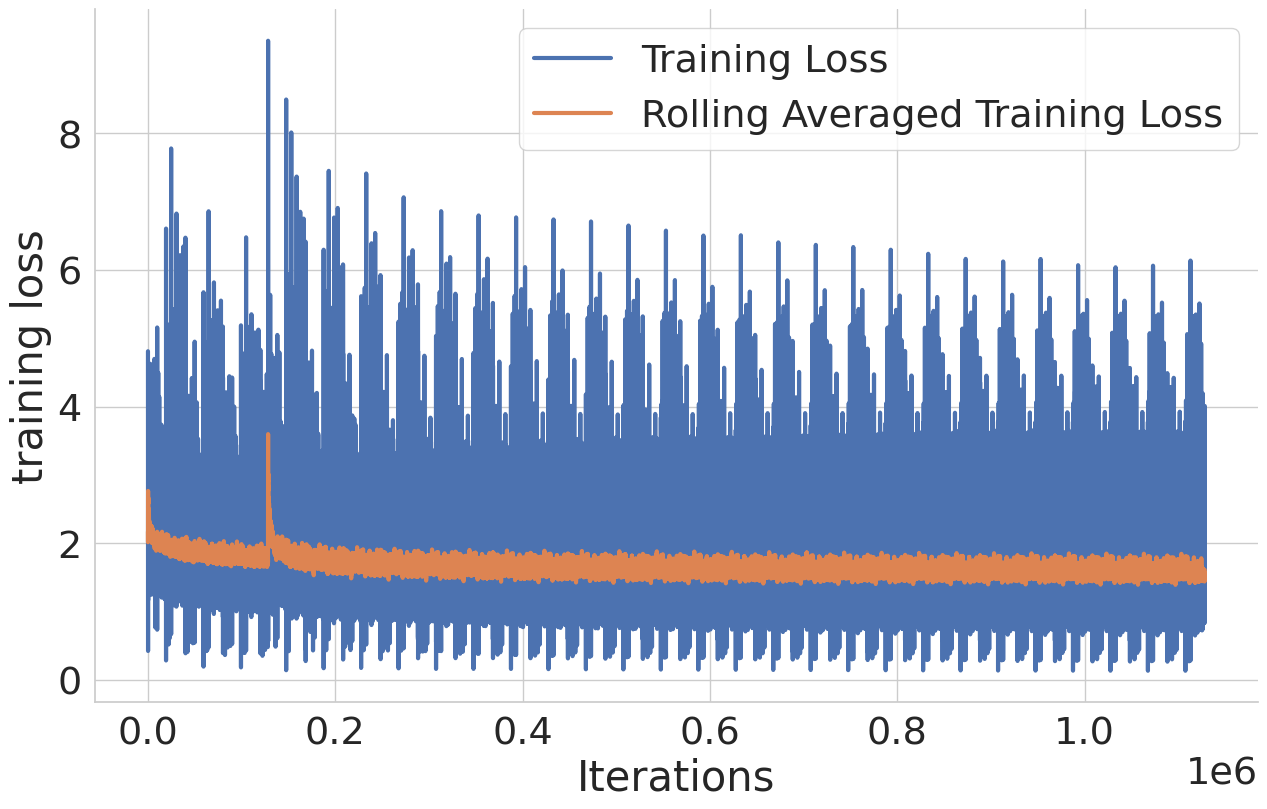

In [38]:
# Plot the training loss and rolling mean training loss with respect to iterations
# Feel free to change the window size
plt.figure(figsize = (15, 9))

plt.plot(train_loss_list, linewidth = 3, label = 'Training Loss')
plt.plot(np.convolve(train_loss_list, np.ones(100), 'valid') / 100,
         linewidth = 3, label = 'Rolling Averaged Training Loss')
plt.ylabel("training loss")
plt.xlabel("Iterations")
plt.legend()
sns.despine()